# Internal Consistency Analysis (Single-Label)

This experiment evaluates internal labeling stability using duplicated survey items.

For each question (`qid`), multiple paraphrased variants exist.
We measure how consistently these variants are assigned to the same
wellness dimension within a single source.

We compare two systems:

- Human annotators (single-label assignments)
- LLM semantic mapping (Top-1 dimension only)

## JSD in Our Internal Evaluation Setting

In the internal (duplicate-question) experiment,  
Jensen–Shannon Divergence (JSD) measures how consistently a single source assigns dimensions across paraphrased variants of the same question (`qid`).

For a fixed source $$ s $$ and duplicated question $$ q $$:

Assume there are $$ n = 5 $$ paraphrased variants.

---

### Step 1 — Construct the empirical distribution

Example:

A human annotator assigns the following Top-1 dimensions:

- Emotional  
- Emotional  
- Cognitive  
- Emotional  
- Cognitive  

This yields the empirical distribution over 8 dimensions:

$$
P = [0.6, 0.4, 0, 0, 0, 0, 0, 0]
$$

(3 Emotional, 2 Cognitive.)

Now consider a perfectly stable case where all variants map to the same dimension:

- Emotional  
- Emotional  
- Emotional  
- Emotional  
- Emotional  

The distribution becomes:

$$
Q = [1, 0, 0, 0, 0, 0, 0, 0]
$$

---

### Step 2 — Compute JSD

First compute the midpoint distribution:

$$
M = \frac{1}{2}(P + Q)
$$

$$
M = [0.8, 0.2, 0, 0, 0, 0, 0, 0]
$$

JSD is defined as:

$$
\mathrm{JSD}(P \parallel Q)
= \frac{1}{2}\mathrm{KL}(P \parallel M)
+ \frac{1}{2}\mathrm{KL}(Q \parallel M)
$$

where

$$
\mathrm{KL}(P \parallel Q)
= \sum_i P(i)\log_2\frac{P(i)}{Q(i)}
$$

Now compute the two KL terms:

$$
\mathrm{KL}(P \parallel M)
=
0.6 \log_2\frac{0.6}{0.8}
+
0.4 \log_2\frac{0.4}{0.2}
$$

$$
\mathrm{KL}(P \parallel M) \approx 0.151
$$

$$
\mathrm{KL}(Q \parallel M)
=
1 \cdot \log_2\frac{1}{0.8}
$$

$$
\mathrm{KL}(Q \parallel M) \approx 0.322
$$

Therefore,

$$
\mathrm{JSD}(P \parallel Q)
=
\frac{1}{2}(0.151 + 0.322)
$$

$$
\mathrm{JSD}(P \parallel Q)
\approx 0.237
$$

---

### Interpretation

- If all duplicated variants map to the same dimension  
  → distribution is one-hot  
  → $$ \mathrm{JSD} = 0 $$  
  → perfect internal stability  

- If assignments are split across multiple dimensions  
  → probability mass spreads  
  → JSD increases  
  → internal semantic inconsistency increases  

In this example, the mild 3–2 split produces:

$$
\mathrm{JSD} \approx 0.24
$$

which corresponds closely to the empirical human internal score observed in our experiment.

---

### Final Aggregation

For each duplicated question $$ q $$, we compute:

$$
\mathrm{JSD}_q
$$

The overall internal stability score is:

$$
\mathrm{InternalScore}
=
\frac{1}{|\mathcal{Q}|}
\sum_{q \in \mathcal{Q}}
\mathrm{JSD}_q
$$

That is, JSD values are averaged across all duplicated `qid`.

This provides a scalar measure of internal semantic coherence under paraphrasing.

In [ ]:
from pathlib import Path
from mhdr.dataloader.io import read_csv, save_csv
INPUT_DIR = Path.cwd() / "input"
OUTPUT_DIR = Path.cwd() / "output"
TEMP_DIR = Path.cwd() / "temp"
HUMAN_DATA = read_csv(INPUT_DIR / "human_dup.csv")


In [ ]:
from mhdr.model.semantic_mapper import SemanticMapper
from mhdr.model.LLMio import load_dimension_sets
import pandas as pd
dimension_sets = load_dimension_sets(INPUT_DIR / "dim_definations.csv")

deltas = [0.05]

# 1) init once
mapper = SemanticMapper()
mapper.set_questions_df(HUMAN_DATA, text_col="text_norm")  # encode once

all_mapped = mapper.map_to_llm_dimension_definitions(
    dimension_sets,
    deltas=deltas,
)

exact_top1 = mapper.extract_top1_from_mapped(all_mapped, text_col='text_norm')
save_csv(exact_top1, TEMP_DIR / f"llm_dup.csv")

# 3) sanity checks
print("\nMerged shape:", exact_top1.shape)
print("Unique models:", exact_top1["source"].unique())
print("Unique dimensions:", exact_top1["answer"].nunique())

/Users/haikeyu/Desktop/mentalhealth-dimension-reduction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1079.19it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Mapping using ChatGPT-5.2 ===

=== Mapping using DeepSeek-V3.2 ===

=== Mapping using Llama-4 ===

=== Mapping using claude-sonnet-4.5 ===

=== Mapping using gemini-3.0-pro ===

Merged shape: (7280, 4)
Unique models: <StringArray>
[      'ChatGPT-5.2',     'DeepSeek-V3.2',           'Llama-4',
 'claude-sonnet-4.5',    'gemini-3.0-pro']
Length: 5, dtype: str
Unique dimensions: 8


In [ ]:
from mhdr.evaluator.internal_evaluator import InternalEvaluator
ev = InternalEvaluator(HUMAN_DATA, exact_top1)

(h_runs, h_sum, _), (l_runs, l_sum, _) = ev.compare_human_vs_llm(
    k_sources=3,   # human sampled to 5, llm sampled to 5 (if llm exactly 5 -> full set)
    times=100,
    seed=42,
    qid_col="qid",
    source_col="source",
    label_col="answer",
)

print(h_sum)
print(l_sum)

   which  k_sources  times      mean    median       p10     p90
0  human          5    100  0.071567  0.065434  0.036722  0.1134
  which  k_sources  times  mean  median  p10  p90
0   llm          5    100   0.0     0.0  0.0  0.0


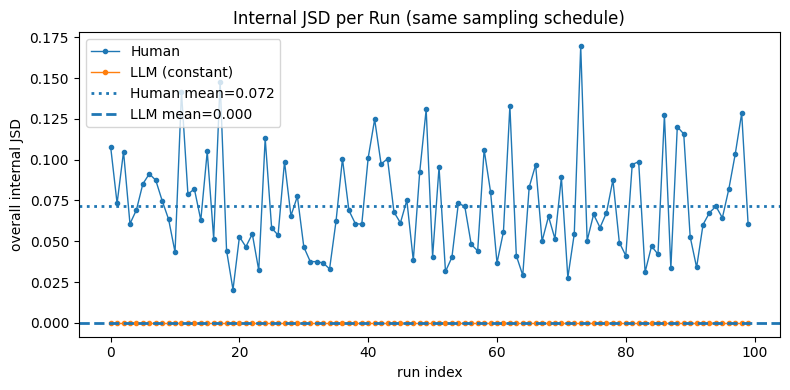

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

overall_col = "overall"

hr = h_runs.sort_values("run")[overall_col].to_numpy()
lr = l_runs.sort_values("run")[overall_col].to_numpy()
x = np.arange(len(hr))

plt.figure(figsize=(8,4))
plt.plot(x, hr, marker="o", linewidth=1, markersize=3, label="Human")
plt.plot(x, lr, marker="o", linewidth=1, markersize=3, label="LLM (constant)")
plt.axhline(np.mean(hr), linestyle=":", linewidth=2, label=f"Human mean={np.mean(hr):.3f}")
plt.axhline(np.mean(lr), linestyle="--", linewidth=2, label=f"LLM mean={np.mean(lr):.3f}")
plt.title("Internal JSD per Run (same sampling schedule)")
plt.xlabel("run index")
plt.ylabel("overall internal JSD")
plt.legend()
plt.tight_layout()
plt.show()